### 1.4.5.3. LRC Series Circuits

$$
L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac{1}{C}q = E(t),
\qquad i = \frac{dq}{dt} .
$$

**Explanation:**

By Kirchhoff's voltage law the inductor, resistor, and capacitor voltage drops sum to the impressed voltage $E(t)$, giving a second-order equation for the charge $q(t)$ that is the *exact analogue* of the [driven spring/mass](./02_driven_motion_and_resonance.ipynb) system: inductance $L \leftrightarrow$ mass $m$, resistance $R \leftrightarrow$ damping $\beta$, inverse capacitance $1/C \leftrightarrow$ stiffness $k$, and voltage $E \leftrightarrow$ force $f$. With $E = 0$ the discriminant $R^2 - 4L/C$ classifies the circuit as over-, critically, or underdamped, and every free response carries the decay factor $e^{-Rt/2L}$. This mechanical–electrical analogy is why one second-order theory serves both, and the LRC circuit is the canonical electrical plant in control.

**Intuition:**

<p align="center">
  <img src="../../../Figures/01040503_lrc_series_circuit.jpeg"
       alt="An LRC series circuit with voltage source E, inductor L, resistor R, and capacitor C"
       width="260">
</p>

**Numerical Example:**

Find the charge $q(t)$ for $L = 0.25$ H, $R = 10\ \Omega$, $C = 0.001$ F, $E(t) = 0$, $q(0) = q_0$, $i(0) = q'(0) = 0$.

**Step 1 — form the equation.** Since $1/C = 1000$,

$$
\tfrac14 q'' + 10 q' + 1000 q = 0 \;\Longrightarrow\; q'' + 40 q' + 4000 q = 0 .
$$

**Step 2 — classify and solve.** The discriminant $R^2 - 4L/C = 100 - 1000 < 0$, so the circuit is **underdamped**. The auxiliary equation $m^2 + 40m + 4000 = 0$ has roots $m = -20 \pm 60i$, giving

$$
q(t) = e^{-20t}\big(c_1\cos 60t + c_2\sin 60t\big).
$$

**Step 3 — apply initial conditions.** $q(0) = q_0$ gives $c_1 = q_0$; differentiating and using $i(0) = q'(0) = 0$ gives $-20c_1 + 60c_2 = 0$, so $c_2 = \tfrac13 q_0$. Hence

$$
q(t) = q_0\,e^{-20t}\!\left(\cos 60t + \tfrac13\sin 60t\right),
$$

the capacitor charging and discharging while the oscillation decays.

In [1]:
import sympy as sp

t = sp.symbols("t")
q_0 = sp.symbols("q_0")
q = sp.Function("q")

circuit = sp.Eq(q(t).diff(t, 2) + 40 * q(t).diff(t) + 4000 * q(t), 0)
discriminant = 10**2 - 4 * sp.Rational(1, 4) / sp.Rational(1, 1000)
solution = sp.dsolve(circuit, q(t), ics={q(0): q_0, q(t).diff(t).subs(t, 0): 0})

print("R^2 - 4L/C =", discriminant, "-> underdamped")
print("q(t) =", solution.rhs)

R^2 - 4L/C = -900 -> underdamped
q(t) = (q_0*sin(60*t)/3 + q_0*cos(60*t))*exp(-20*t)


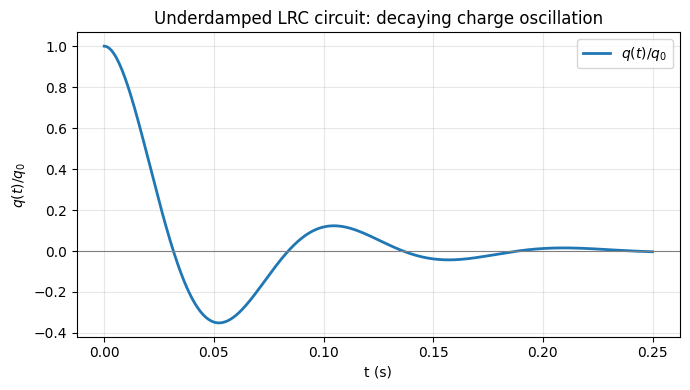

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 0.25, 400)
charge = np.exp(-20 * time) * (np.cos(60 * time) + (1 / 3) * np.sin(60 * time))

plt.figure(figsize=(7, 4))
plt.plot(time, charge, linewidth=2, label=r"$q(t)/q_0$")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("t (s)"); plt.ylabel(r"$q(t)/q_0$"); plt.title("Underdamped LRC circuit: decaying charge oscillation")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Driven Motion and Resonance](./02_driven_motion_and_resonance.ipynb) | [Next: Definition of the Laplace Transform ➡️](../06_Laplace_Transforms/01_definition_of_the_laplace_transform.ipynb)